# 3.0 Model training - Ridge


## Imports


In [1]:
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
)
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    create_model_pipeline,
    evaluate_model,
    create_model_gridsearch
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred

2025-12-17 19:18:26.785 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
ALPHA = 1000
USE_PCA = False
N_COMPONENTS = 0.95
CV_SPLITS = 5

TEST_SIZE = 0.2  
CUTOFF_DATE = None  

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 49)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
dates = features[VISIT_DATE_COL].copy()
restaurant_ids = features[AIR_RESTAURANT_ID_COL].copy() 

X = features.drop(columns=[AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, DAY_OF_WEEK_COL, VISITORS_NBR_COL])
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False, random_state=42
)

split_idx = len(X_train)
train_dates = dates.iloc[:split_idx].reset_index(drop=True)
test_dates = dates.iloc[split_idx:].reset_index(drop=True)

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-02-16 00:00:00
Test set dates: 2017-02-16 00:00:00 to 2017-04-22 00:00:00


In [7]:
model = create_model_pipeline(
    alpha=ALPHA,
    use_pca=USE_PCA,
    n_components=N_COMPONENTS,
)

## Cross-validation


In [8]:
cv_results = evaluate_model(model, X_train, y_train, cv_splits=CV_SPLITS)

print("Cross-validation results:")
print(f"RMSE: {cv_results['rmse_mean']:.4f} +- {cv_results['rmse_std']:.4f}")
print(f"MAE:  {cv_results['mae_mean']:.4f} +- {cv_results['mae_std']:.4f}")
print(f"R2:   {cv_results['r2_mean']:.4f} +- {cv_results['r2_std']:.4f}")
print(f"\nPer-fold scores:")
for i, (rmse, mae, r2) in enumerate(
    zip(cv_results["rmse_scores"], cv_results["mae_scores"], cv_results["r2_scores"]), 1
):
    print(f"Fold {i}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")


Cross-validation results:
RMSE: 11.3994 +- 0.7347
MAE:  7.2384 +- 0.4700
R2:   0.5215 +- 0.0694

Per-fold scores:
Fold 1: RMSE=10.8141, MAE=7.3052, R2=0.5664
Fold 2: RMSE=10.9258, MAE=6.9390, R2=0.5388
Fold 3: RMSE=10.6731, MAE=7.0007, R2=0.5706
Fold 4: RMSE=12.3661, MAE=8.1229, R2=0.5468
Fold 5: RMSE=12.2179, MAE=6.8243, R2=0.3848


## Train


I haven't added the feature update (lags and rolling) yet.

In [9]:
grid_search = create_model_gridsearch(verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 63 candidates, totalling 189 fits
Best parameters: {'ridge__alpha': np.float64(1000.0), 'selector__estimator__alpha': 0.1, 'selector__threshold': 0.0001}
Best score: -11.385796171998924


In [10]:
model = grid_search.best_estimator_
sel = model.named_steps.get("selector", None)
support = sel.get_support()
selected_cols = X.columns[support]

print("Selected features:", list(selected_cols))

Selected features: ['opened_recently', 'holiday_flg', 'golden_week_flg', 'open_usually', 'days_from_last_visit', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_nbrs_mean_7', 'visitors_nbrs_std_7', 'visitors_nbrs_median_14', 'visitors_nbrs_median_28', 'visitors_last_month', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28']


In [11]:
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
# y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
# test_mae = mean_absolute_error(y_test, y_test_pred)
# test_r2 = r2_score(y_test, y_test_pred)

print(f"Train set metrics:")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

# print(f"\nTest set metrics:")
# print(f"RMSE: {test_rmse:.4f}")
# print(f"MAE:  {test_mae:.4f}")
# print(f"R2:   {test_r2:.4f}")


Train set metrics:
RMSE: 11.1049
MAE:  7.2942
R2:   0.5620


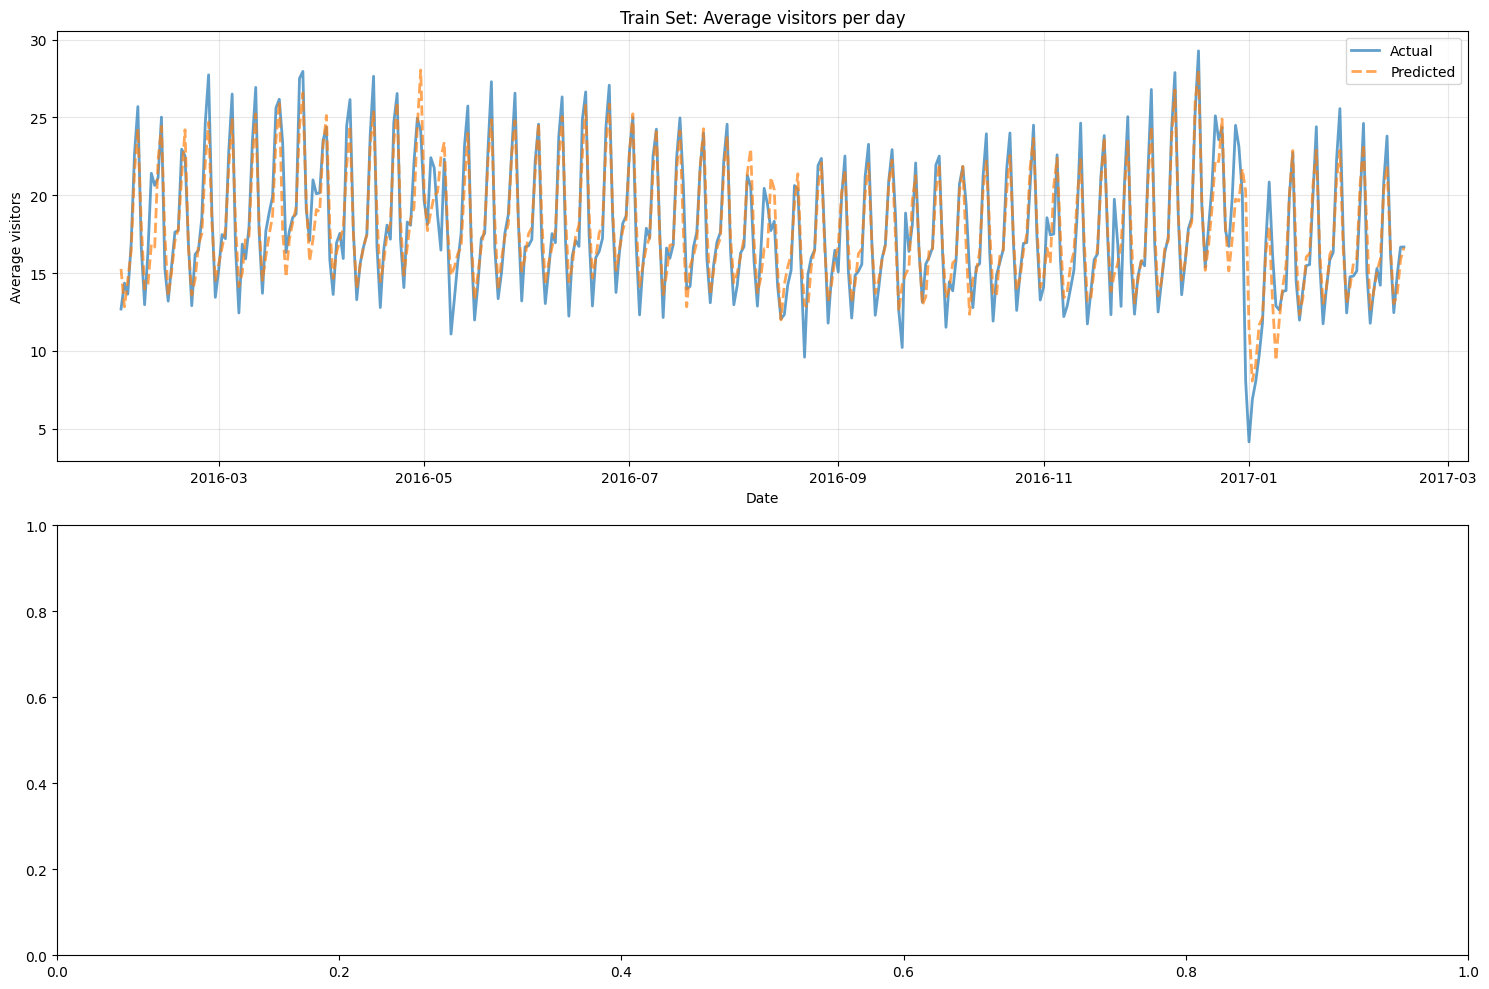

In [12]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
# test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
# plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

In [14]:
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

In [15]:
recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
)

KeyError: 'visit_date'

## Saving model

In [13]:
joblib.dump(model, MODEL_PATH)

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    else:
        return obj

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
    "selected_features": list(selected_cols) if 'selected_cols' in globals() else None,
    "n_features": len(selected_cols) if 'selected_cols' in globals() else None,
}

params_path = MODELS_DIR / "ridge_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)